# 0. ENVIRONMENT SETUP & OPTIMIZATIONS

In [1]:
# TensorFlow environment initialization, GPU optimization, mixed precision, and library imports.

import tensorflow as tf
from tensorflow.keras import mixed_precision
import numpy as np
import pandas as pd
import json
import os
import zipfile
import datetime
import shutil
import tensorboard

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("GPUs Available:", gpus)
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.optimizer.set_jit(True)
        print(" XLA JIT enabled.")
    except RuntimeError as e:
        print(e)

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Compute dtype:", policy.compute_dtype)
print("Variable dtype:", policy.variable_dtype)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorBoard version:", tensorboard.__version__)

2026-05-31 04:11:46.646031: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780200706.846151      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780200706.902884      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780200707.355981      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780200707.356054      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780200707.356058      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
 XLA JIT enabled.
Compute dtype: float16
Variable dtype: float32
TensorBoard version: 2.19.0


# 1. Extract Processed Dataset

In [2]:
PROCESSED_INPUT_DIR = "/kaggle/input/datasets/gilangagung/qlop-intelligent-learning-recommendation-dataset"
PROCESSED_DIR = "/kaggle/working/processed"

if os.path.exists(PROCESSED_INPUT_DIR):
    if os.path.exists(PROCESSED_DIR):
        shutil.rmtree(PROCESSED_DIR)
        
    shutil.copytree(PROCESSED_INPUT_DIR, PROCESSED_DIR)
    print("Processed data copied to working directory.")
    print("Files:", os.listdir(PROCESSED_DIR))
else:
    print(f"Error: Folder {PROCESSED_INPUT_DIR} not found.")
    
print("Processed data Copied.")
print("Files:", os.listdir(PROCESSED_DIR))


Processed data copied to working directory.
Files: ['synthetic_demand_course_two_tower.npz', 'unique_skills_raw.txt', 'train_test_split_info.json', 'role_freq.json', 'linkedin_to_coursera_mapping.json', 'synthetic_users_skill_priority_scorer.npz', 'coursera_cleaned.csv', 'skill_vocab_linkedin.json', 'skill_vocab_coursera.json']
Processed data Copied.
Files: ['synthetic_demand_course_two_tower.npz', 'unique_skills_raw.txt', 'train_test_split_info.json', 'role_freq.json', 'linkedin_to_coursera_mapping.json', 'synthetic_users_skill_priority_scorer.npz', 'coursera_cleaned.csv', 'skill_vocab_linkedin.json', 'skill_vocab_coursera.json']


# 2. Load Vocabulary And Data Synthetis

In [3]:
# Loading vocabularies, mappings, synthetic user data, and training-validation splits.

vocab_li_path = os.path.join(PROCESSED_DIR, "skill_vocab_linkedin.json")
with open(vocab_li_path, 'r') as f:
    vocab_li = json.load(f)
skill_to_idx_li = vocab_li["skill_to_idx"]
idx_to_skill_li = vocab_li["idx_to_skill"]
N_SKILLS_LI = vocab_li["vocab_size"]
print(f"Vocabulary LinkedIn size: {N_SKILLS_LI}")

vocab_cr_path = os.path.join(PROCESSED_DIR, "skill_vocab_coursera.json")
with open(vocab_cr_path, 'r') as f:
    vocab_cr = json.load(f)
skill_to_idx_cr = vocab_cr["skill_to_idx"]
idx_to_skill_cr = vocab_cr["idx_to_skill"]
N_SKILLS_CR = vocab_cr["vocab_size"]
print(f"Vocabulary Coursera size: {N_SKILLS_CR}")

mapping_path = os.path.join(PROCESSED_DIR, "linkedin_to_coursera_mapping.json")
with open(mapping_path, 'r') as f:
    linkedin_to_coursera = json.load(f)
print(f"Mapping loaded, entries: {len(linkedin_to_coursera)}")

users_npz = np.load(os.path.join(PROCESSED_DIR, "synthetic_users_skill_priority_scorer.npz"))
X_users = users_npz["X_users"]
X_roles_idx = users_npz["X_roles"]
Y_targets = users_npz["Y_targets"]
role_list = users_npz["role_list"]
N_ROLES = len(role_list)
role_to_idx = {role: i for i, role in enumerate(role_list)}
idx_to_role = {i: role for role, i in role_to_idx.items()}
print(f"Users: {X_users.shape}, Roles: {N_ROLES}")

demand_npz = np.load(os.path.join(PROCESSED_DIR, "synthetic_demand_course_two_tower.npz"))
demand_vectors = demand_npz["demand_vectors"]
course_vectors_all = demand_npz["course_vectors"]
course_indices = demand_npz["course_indices"]
targets_demand = demand_npz["targets"]
course_names = demand_npz["course_names"]
course_urls = demand_npz["course_urls"]
num_courses = len(course_names)
print(f"Demand: {demand_vectors.shape}, Courses: {num_courses}")

coursera_csv = os.path.join(PROCESSED_DIR, "coursera_cleaned.csv")
df_coursera = pd.read_csv(coursera_csv)
print(f"Coursera dataframe loaded: {df_coursera.shape}")

split_path = os.path.join(PROCESSED_DIR, "train_test_split_info.json")
with open(split_path, 'r') as f:
    split_info = json.load(f)
train_idx_u = split_info["skill_priority_scorer"]["train_indices"]
val_idx_u   = split_info["skill_priority_scorer"]["val_indices"]
train_idx_d = split_info["two_tower_course"]["train_indices"]
val_idx_d   = split_info["two_tower_course"]["val_indices"]
test_idx_u = split_info["skill_priority_scorer"]["test_indices"]
test_idx_d = split_info["two_tower_course"]["test_indices"]

Vocabulary LinkedIn size: 489
Vocabulary Coursera size: 1999
Mapping loaded, entries: 251
Users: (20000, 489), Roles: 27
Demand: (15000, 489), Courses: 1980
Coursera dataframe loaded: (1980, 27)


# 3. Custom Loss, Callback, & Layers

In [4]:
class WeightedMAE(tf.keras.losses.Loss):
    def __init__(self, alpha=2.0, name="weighted_mae"):
        super().__init__(name=name)
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        weights = 1.0 + self.alpha * y_true
        absolute_error = tf.abs(y_true - y_pred)
        weighted_error = weights * absolute_error
        return tf.reduce_mean(weighted_error)

class EarlyStoppingOnTargetMAE(tf.keras.callbacks.Callback):
    def __init__(self, target_mae=0.02, save_path="./best_model"):
        super().__init__()
        self.target_mae = target_mae
        self.save_path = save_path
        self.best_mae = np.inf
        self.stopped = False

    def on_epoch_end(self, epoch, logs=None):
        current_mae = logs.get("val_mae")
        if current_mae is not None:
            if current_mae < self.best_mae:
                self.best_mae = current_mae
                self.model.export(self.save_path)
                print(f"\nModel improved at epoch {epoch+1} (MAE: {current_mae:.4f}). Saved.")
            if current_mae <= self.target_mae:
                print(f"\nTarget MAE {self.target_mae} reached at epoch {epoch+1}. Stopping training.")
                self.stopped = True

class InteractionLayer(tf.keras.layers.Layer):
    def __init__(self, embed_dim=32):
        super(InteractionLayer, self).__init__()
        self.embed_dim = embed_dim
        self.w = self.add_weight(
            shape=(embed_dim, embed_dim),
            initializer='random_normal',
            trainable=True,
            name='interaction_weight',
            dtype=tf.float32
        )

    def call(self, demand_emb, course_emb):
        demand_emb = tf.cast(demand_emb, tf.float32)
        course_emb = tf.cast(course_emb, tf.float32)
        w_float32 = tf.cast(self.w, tf.float32)
        demand_transformed = tf.matmul(demand_emb, w_float32)
        interaction = tf.reduce_sum(demand_transformed * course_emb, axis=1, keepdims=True)
        return interaction

print("Custom components defined.")

Custom components defined.


# 4. SKILL PRIORITY SCORER (Model 3) Build & Train dengan Optimasi Pipeline

In [5]:
# Model building, data pipelining, training loop, and training visualizations for SkillPriorityScorer.

def build_model3(N_SKILLS_LI, N_ROLES, embedding_dim=8):
    input_skills = tf.keras.layers.Input(shape=(N_SKILLS_LI,), dtype=tf.float32, name="user_skills")
    input_role = tf.keras.layers.Input(shape=(1,), dtype=tf.int32, name="role_index")
    role_emb = tf.keras.layers.Embedding(input_dim=N_ROLES, output_dim=embedding_dim, name="role_embedding")(input_role)
    role_emb = tf.keras.layers.Flatten()(role_emb)
    concat = tf.keras.layers.Concatenate()([input_skills, role_emb])
    x = tf.keras.layers.Dense(128, activation='relu', name="dense1")(concat)
    x = tf.keras.layers.Dropout(0.3, name="dropout1")(x)
    x = tf.keras.layers.Dense(64, activation='relu', name="dense2")(x)
    output = tf.keras.layers.Dense(N_SKILLS_LI, activation='sigmoid', dtype=tf.float32, name="output")(x)
    return tf.keras.Model(inputs=[input_skills, input_role], outputs=output, name="SkillPriorityScorer")

model3 = build_model3(N_SKILLS_LI, N_ROLES)
model3.summary()

BATCH_SIZE = 64
X_train_skills = X_users[train_idx_u]
X_train_roles = X_roles_idx[train_idx_u].reshape(-1, 1)
y_train = Y_targets[train_idx_u]
X_val_skills = X_users[val_idx_u]
X_val_roles = X_roles_idx[val_idx_u].reshape(-1, 1)
y_val = Y_targets[val_idx_u]

train_ds = tf.data.Dataset.from_tensor_slices(((X_train_skills, X_train_roles), y_train))
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(((X_val_skills, X_val_roles), y_val))
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

loss_fn = WeightedMAE(alpha=2.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

train_loss = tf.keras.metrics.Mean(name='train_loss')
train_mae = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
train_acc = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='train_acc')
val_loss = tf.keras.metrics.Mean(name='val_loss')
val_mae = tf.keras.metrics.MeanAbsoluteError(name='val_mae')
val_acc = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='val_acc')

log_dir = "/kaggle/working/logs/skill_priority_scorer/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = tf.summary.create_file_writer(log_dir)

os.makedirs("/kaggle/working/models/skill_priority_scorer_savedmodel", exist_ok=True)
early_stop3 = EarlyStoppingOnTargetMAE(target_mae=0.02, save_path="/kaggle/working/models/skill_priority_scorer_savedmodel")

@tf.function
def train_step3(x, y):
    with tf.GradientTape() as tape:
        predictions = model3(x, training=True)
        loss = loss_fn(y, predictions)
    gradients = tape.gradient(loss, model3.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model3.trainable_variables))
    train_loss.update_state(loss)
    train_mae.update_state(y, predictions)
    y_bin = tf.cast(y > 0.5, tf.float32)
    pred_bin = tf.cast(predictions > 0.5, tf.float32)
    train_acc.update_state(y_bin, pred_bin)

def val_step3(x, y):
    predictions = model3(x, training=False)
    loss = loss_fn(y, predictions)
    val_loss.update_state(loss)
    val_mae.update_state(y, predictions)
    y_bin = tf.cast(y > 0.5, tf.float32)
    pred_bin = tf.cast(predictions > 0.5, tf.float32)
    val_acc.update_state(y_bin, pred_bin)

history = {'loss':[], 'mae':[], 'acc':[], 'val_loss':[], 'val_mae':[], 'val_acc':[]}

EPOCHS = 30
print("Start training Skill Priority Scorer Model...")
for epoch in range(EPOCHS):
    train_loss.reset_state()
    train_mae.reset_state()
    train_acc.reset_state()
    val_loss.reset_state()
    val_mae.reset_state()
    val_acc.reset_state()
    
    for step, (x_batch, y_batch) in enumerate(train_ds):
        train_step3(x_batch, y_batch)
    for x_val_batch, y_val_batch in val_ds:
        val_step3(x_val_batch, y_val_batch)
    
    t_l = train_loss.result().numpy()
    t_m = train_mae.result().numpy()
    t_a = train_acc.result().numpy()
    v_l = val_loss.result().numpy()
    v_m = val_mae.result().numpy()
    v_a = val_acc.result().numpy()
    
    history['loss'].append(t_l)
    history['mae'].append(t_m)
    history['acc'].append(t_a)
    history['val_loss'].append(v_l)
    history['val_mae'].append(v_m)
    history['val_acc'].append(v_a)
    
    with summary_writer.as_default():
        tf.summary.scalar('loss/train', t_l, step=epoch)
        tf.summary.scalar('mae/train', t_m, step=epoch)
        tf.summary.scalar('accuracy/train', t_a, step=epoch)
        tf.summary.scalar('loss/val', v_l, step=epoch)
        tf.summary.scalar('mae/val', v_m, step=epoch)
        tf.summary.scalar('accuracy/val', v_a, step=epoch)
    
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {t_l:.4f} MAE: {t_m:.4f} Acc: {t_a:.4f} | Val Loss: {v_l:.4f} MAE: {v_m:.4f} Acc: {v_a:.4f}")
    
    early_stop3.set_model(model3)
    early_stop3.on_epoch_end(epoch, {"val_mae": v_m, "val_loss": v_l})
    if early_stop3.stopped:
        print("Training stopped by callback.")
        break

model3.export("/kaggle/working/models/skill_priority_scorer_savedmodel")
print("Skill Priority Scorer model final saved.")


I0000 00:00:1780200734.437672      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780200734.443967      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "SkillPriorityScorer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ role_index          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ role_embedding      │ (None, 1, 8)      │        216 │ role_index[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_skills         │ (None, 489)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ role_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 497)       │          0 │ user_skills[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 128)       │     63,744 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 128)       │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 64)        │      8,256 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 489)       │     31,785 │ dense2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 104,001 (406.25 KB)

 Trainable params: 104,001 (406.25 KB)

...

Saved artifact at '/kaggle/working/models/skill_priority_scorer_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float32, name='user_skills'), TensorSpec(shape=(None, 1), dtype=tf.int32, name='role_index')]
Output Type:
  TensorSpec(shape=(None, 489), dtype=tf.float32, name=None)
Captures:
  135084532888400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532888592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532880720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532890704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532890512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084511658448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084511659024: TensorSpec(shape=(), dtype=tf.resource, name=None)

Model improved at epoch 19 (MAE: 0.0201). Saved.
Epoch 20/30 | Train Loss: 0.0331 MAE: 0.0215 Acc: 0.9903 | Val Loss: 0.030

INFO:tensorflow:Assets written to: /kaggle/working/models/skill_priority_scorer_savedmodel/assets


Saved artifact at '/kaggle/working/models/skill_priority_scorer_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float32, name='user_skills'), TensorSpec(shape=(None, 1), dtype=tf.int32, name='role_index')]
Output Type:
  TensorSpec(shape=(None, 489), dtype=tf.float32, name=None)
Captures:
  135084532888400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532888592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532880720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532890704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532890512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084511658448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084511659024: TensorSpec(shape=(), dtype=tf.resource, name=None)

Model improved at epoch 20 (MAE: 0.0197). Saved.

Target MAE 0.02 reached at epoch 20. Stopping training.
Training stopped 

INFO:tensorflow:Assets written to: /kaggle/working/models/skill_priority_scorer_savedmodel/assets


Saved artifact at '/kaggle/working/models/skill_priority_scorer_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float32, name='user_skills'), TensorSpec(shape=(None, 1), dtype=tf.int32, name='role_index')]
Output Type:
  TensorSpec(shape=(None, 489), dtype=tf.float32, name=None)
Captures:
  135084532888400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532888592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532880720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532890704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084532890512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084511658448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135084511659024: TensorSpec(shape=(), dtype=tf.resource, name=None)
Skill Priority Scorer model final saved.


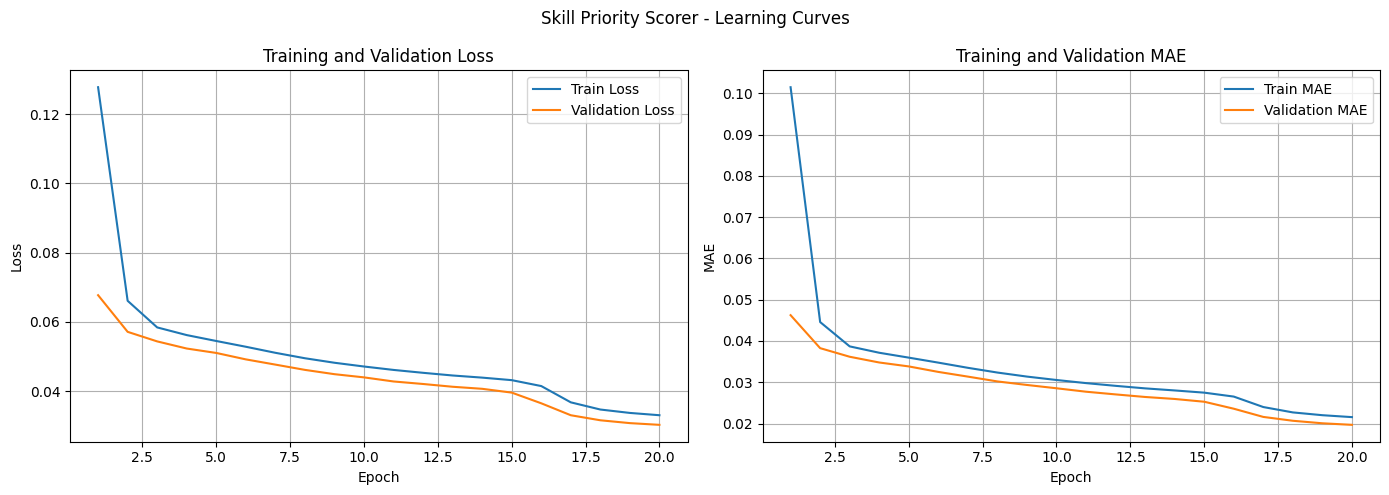

Fig 1: Learning curves (loss & MAE) indicate convergence and potential overfitting.


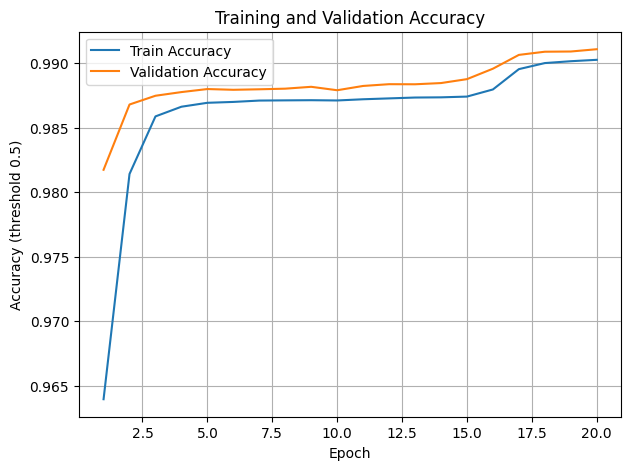

Fig 2: Accuracy curves show classification performance at threshold 0.5.


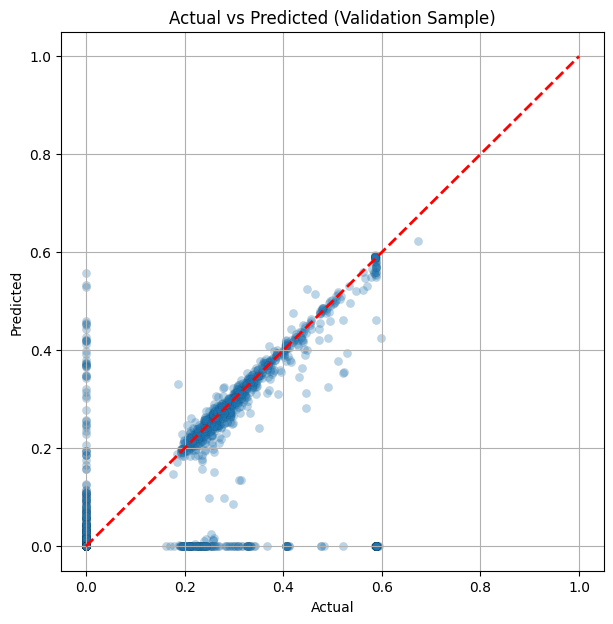

Fig 3: Scatter of actual vs predicted. Ideal points lie on the red diagonal.


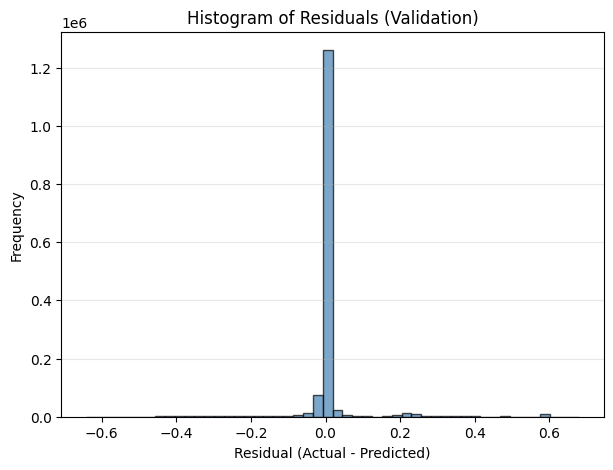

Fig 4: Residual distribution should be centered near zero.


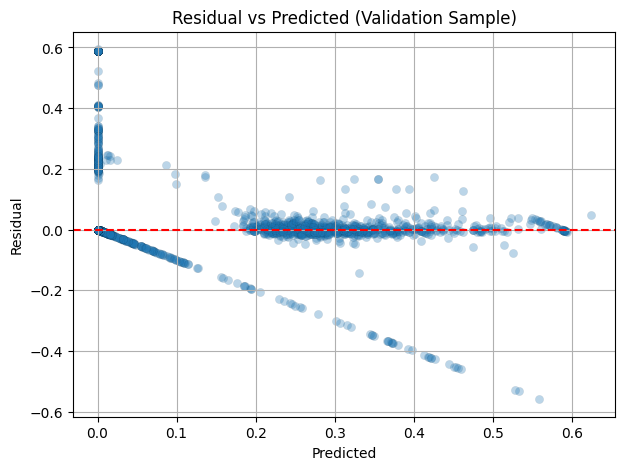

Fig 5: Residual vs predicted reveals heteroscedasticity or bias.


In [10]:
import matplotlib.pyplot as plt
import numpy as np

epochs_range = range(1, len(history['loss'])+1)

# 1. Loss and MAE curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, history['loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history['mae'], label='Train MAE')
ax2.plot(epochs_range, history['val_mae'], label='Validation MAE')
ax2.set_title('Training and Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)
plt.suptitle('Skill Priority Scorer - Learning Curves')
plt.tight_layout()
plt.show()
print("Fig 1: Learning curves (loss & MAE) indicate convergence and potential overfitting.")

# 2. Accuracy curves
plt.figure(figsize=(7,5))
plt.plot(epochs_range, history['acc'], label='Train Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (threshold 0.5)')
plt.legend()
plt.grid(True)
plt.show()
print("Fig 2: Accuracy curves show classification performance at threshold 0.5.")

# 3. Scatter plot actual vs predicted (on validation set)
val_preds = model3.predict(val_ds, verbose=0)
y_val_flat = y_val.flatten()
preds_flat = val_preds.flatten()
# subsample for clarity
indices = np.random.choice(len(y_val_flat), size=min(5000, len(y_val_flat)), replace=False)
plt.figure(figsize=(7,7))
plt.scatter(y_val_flat[indices], preds_flat[indices], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.plot([0,1], [0,1], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Validation Sample)')
plt.grid(True)
plt.show()
print("Fig 3: Scatter of actual vs predicted. Ideal points lie on the red diagonal.")

# 4. Histogram of residuals (validation)
residuals = y_val_flat - preds_flat
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Residuals (Validation)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 4: Residual distribution should be centered near zero.")

# 5. Residual vs Predicted (validation)
plt.figure(figsize=(7,5))
plt.scatter(preds_flat[indices], residuals[indices], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual vs Predicted (Validation Sample)')
plt.grid(True)
plt.show()
print("Fig 5: Residual vs predicted reveals heteroscedasticity or bias.")

Test MAE: 0.0196, Test MSE: 0.0062, Test Accuracy (threshold 0.5): 0.9912


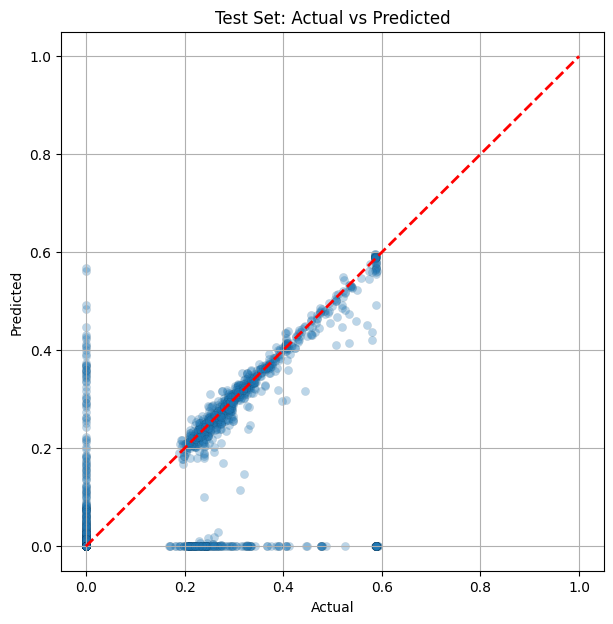

Fig 1: Scatter of actual vs predicted. Points close to diagonal indicate good predictions.


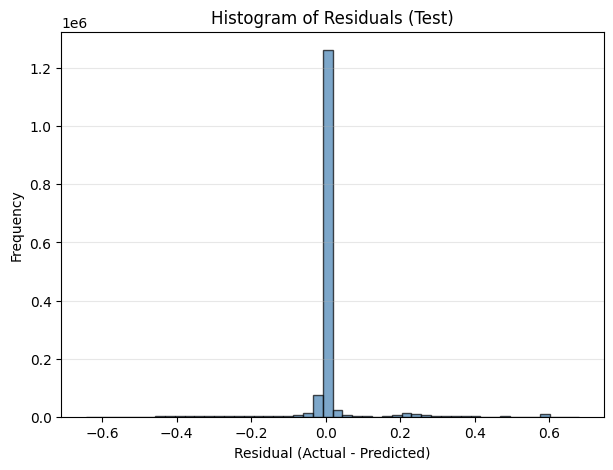

Fig 2: Residual distribution centered near zero shows unbiased predictions.


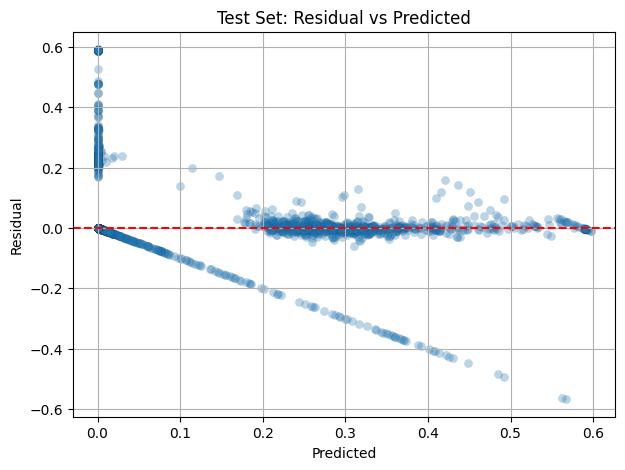

Fig 3: Residual vs predicted reveals heteroscedasticity if funnel shape appears.


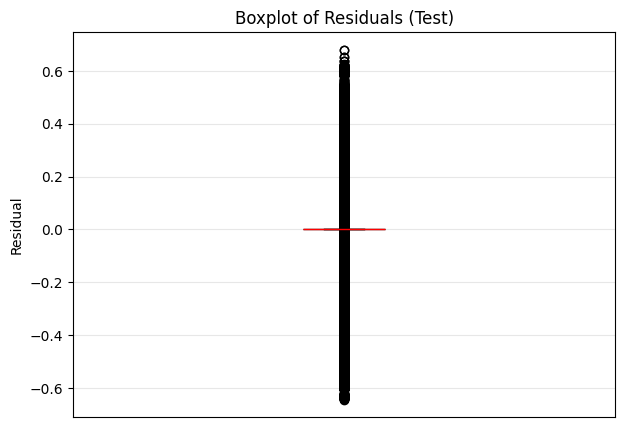

Fig 4: Boxplot shows the spread and symmetry of residuals.


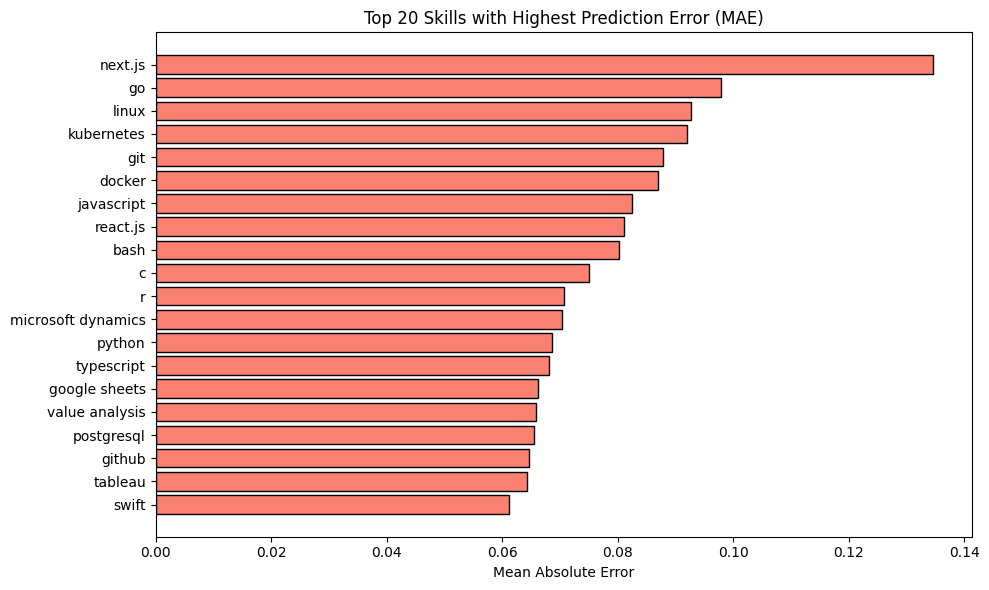

Fig 5: Skills with high MAE might be under-represented or have ambiguous patterns.


In [12]:
# Skill Priority Scorer Testing: load best model, evaluate on test set, compute metrics, and plot 5 diagnostic visualizations.

import matplotlib.pyplot as plt
import numpy as np

# Load best saved model
best_model3 = tf.saved_model.load("/kaggle/working/models/skill_priority_scorer_savedmodel")
infer_best3 = best_model3.signatures['serving_default']

# Prepare test data
X_test_skills = X_users[test_idx_u]
X_test_roles = X_roles_idx[test_idx_u].reshape(-1, 1)
y_test = Y_targets[test_idx_u]

# Predict function (batch to avoid OOM)
def predict_skill_priority(model, skills, roles, batch_size=256):
    preds = []
    for i in range(0, len(skills), batch_size):
        batch_skills = tf.constant(skills[i:i+batch_size], dtype=tf.float32)
        batch_roles = tf.constant(roles[i:i+batch_size], dtype=tf.int32)
        out = model(user_skills=batch_skills, role_index=batch_roles)
        preds.append(out['output_0'].numpy())
    return np.concatenate(preds, axis=0)

test_preds = predict_skill_priority(infer_best3, X_test_skills, X_test_roles)

# Flatten for metrics
y_test_flat = y_test.flatten()
preds_flat = test_preds.flatten()

# Compute metrics
mae_test = np.mean(np.abs(y_test_flat - preds_flat))
mse_test = np.mean((y_test_flat - preds_flat)**2)
acc_test = np.mean((y_test_flat > 0.5) == (preds_flat > 0.5))
print(f"Test MAE: {mae_test:.4f}, Test MSE: {mse_test:.4f}, Test Accuracy (threshold 0.5): {acc_test:.4f}")

# 1. Scatter Actual vs Predicted
sample_idx = np.random.choice(len(y_test_flat), size=min(5000, len(y_test_flat)), replace=False)
plt.figure(figsize=(7,7))
plt.scatter(y_test_flat[sample_idx], preds_flat[sample_idx], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.plot([0,1], [0,1], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Test Set: Actual vs Predicted')
plt.grid(True)
plt.show()
print("Fig 1: Scatter of actual vs predicted. Points close to diagonal indicate good predictions.")

# 2. Histogram of Residuals
residuals = y_test_flat - preds_flat
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Residuals (Test)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 2: Residual distribution centered near zero shows unbiased predictions.")

# 3. Residual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(preds_flat[sample_idx], residuals[sample_idx], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Test Set: Residual vs Predicted')
plt.grid(True)
plt.show()
print("Fig 3: Residual vs predicted reveals heteroscedasticity if funnel shape appears.")

# 4. Boxplot of Residuals
plt.figure(figsize=(7,5))
plt.boxplot(residuals, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='red'))
plt.title('Boxplot of Residuals (Test)')
plt.ylabel('Residual')
plt.xticks([])
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 4: Boxplot shows the spread and symmetry of residuals.")

# 5. Mean Absolute Error per Skill
mae_per_skill = np.mean(np.abs(y_test - test_preds), axis=0)
top_difficult_idx = np.argsort(mae_per_skill)[::-1][:20]
top_difficult_names = [idx_to_skill_li[str(i)] for i in top_difficult_idx]
top_mae_values = mae_per_skill[top_difficult_idx]

plt.figure(figsize=(10,6))
plt.barh(range(len(top_difficult_idx)), top_mae_values[::-1], tick_label=top_difficult_names[::-1], color='salmon', edgecolor='black')
plt.title('Top 20 Skills with Highest Prediction Error (MAE)')
plt.xlabel('Mean Absolute Error')
plt.tight_layout()
plt.show()
print("Fig 5: Skills with high MAE might be under-represented or have ambiguous patterns.")

# 5. Two Tower Course Recommendation Model - Training

In [13]:
# Two-tower recommendation model architecture definition, data pipelining, training execution, and training visualizations.

from tensorflow.keras import regularizers

class CrossAttention(tf.keras.layers.Layer):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.att_dense = tf.keras.layers.Dense(dim, activation='sigmoid')

    def call(self, a, b):
        combined = tf.concat([a, b, a * b, a - b], axis=-1)
        weights = self.att_dense(combined)
        a_att = a * weights
        b_att = b * weights
        return a_att, b_att

class TwoTowerModel(tf.keras.Model):
    def __init__(self, input_dim_demand, input_dim_course, embed_dim=32, dropout_rate=0.3, l2_reg=1e-4):
        super().__init__()
        self.demand_tower = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg),
                                  input_shape=(input_dim_demand,)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(64, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embed_dim)
        ], name="DemandTower")

        self.course_tower = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg),
                                  input_shape=(input_dim_course,)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(64, activation='relu',
                                  kernel_regularizer=regularizers.l2(l2_reg)),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embed_dim)
        ], name="CourseTower")

        self.attention = CrossAttention(embed_dim)
        self.interaction = InteractionLayer(embed_dim)
        self.output_act = tf.keras.layers.Activation('sigmoid', dtype=tf.float32)

    def call(self, inputs, training=False):
        demand_vec, course_vec = inputs
        demand_emb = self.demand_tower(demand_vec, training=training)
        course_emb = self.course_tower(course_vec, training=training)
        demand_emb, course_emb = self.attention(demand_emb, course_emb)
        score = self.interaction(demand_emb, course_emb)
        return self.output_act(score)

model4 = TwoTowerModel(input_dim_demand=N_SKILLS_LI,
                       input_dim_course=N_SKILLS_CR,
                       embed_dim=32)

sample_d = tf.random.normal((2, N_SKILLS_LI))
sample_c = tf.random.normal((2, N_SKILLS_CR))
print("Output shape:", model4([sample_d, sample_c]).shape)

course_vectors_selected = course_vectors_all[course_indices]
targets = targets_demand.reshape(-1, 1)

train_demand = demand_vectors[train_idx_d]
train_course = course_vectors_selected[train_idx_d]
train_targets = targets[train_idx_d]
val_demand = demand_vectors[val_idx_d]
val_course = course_vectors_selected[val_idx_d]
val_targets = targets[val_idx_d]

BATCH_SIZE = 64
train_ds4 = tf.data.Dataset.from_tensor_slices(((train_demand, train_course), train_targets))
train_ds4 = train_ds4.shuffle(10000).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
val_ds4 = tf.data.Dataset.from_tensor_slices(((val_demand, val_course), val_targets))
val_ds4 = val_ds4.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

loss_fn4 = WeightedMAE(alpha=2.0)
optimizer4 = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

t_loss4 = tf.keras.metrics.Mean(name='train_loss')
t_mae4 = tf.keras.metrics.MeanAbsoluteError(name='train_mae')
t_acc4 = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='train_acc')
v_loss4 = tf.keras.metrics.Mean(name='val_loss')
v_mae4 = tf.keras.metrics.MeanAbsoluteError(name='val_mae')
v_acc4 = tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='val_acc')

log_dir4 = "/kaggle/working/logs/two_tower_course/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
writer4 = tf.summary.create_file_writer(log_dir4)

os.makedirs("/kaggle/working/models/two_tower_course_model_savedmodel", exist_ok=True)
early_stop4 = EarlyStoppingOnTargetMAE(target_mae=0.02, save_path="/kaggle/working/models/two_tower_course_model_savedmodel")

@tf.function
def train_step4(demand, course, y):
    with tf.GradientTape() as tape:
        predictions = model4([demand, course], training=True)
        loss = loss_fn4(y, predictions)
    gradients = tape.gradient(loss, model4.trainable_variables)
    optimizer4.apply_gradients(zip(gradients, model4.trainable_variables))
    t_loss4.update_state(loss)
    t_mae4.update_state(y, predictions)
    y_bin = tf.cast(y > 0.5, tf.float32)
    pred_bin = tf.cast(predictions > 0.5, tf.float32)
    t_acc4.update_state(y_bin, pred_bin)

def val_step4(demand, course, y):
    predictions = model4([demand, course], training=False)
    loss = loss_fn4(y, predictions)
    v_loss4.update_state(loss)
    v_mae4.update_state(y, predictions)
    y_bin = tf.cast(y > 0.5, tf.float32)
    pred_bin = tf.cast(predictions > 0.5, tf.float32)
    v_acc4.update_state(y_bin, pred_bin)

best_val_mae4 = np.inf
wait = 0
patience = 5
factor = 0.5
min_lr = 1e-6
min_delta = 1e-4

history4 = {'loss':[], 'mae':[], 'acc':[], 'val_loss':[], 'val_mae':[], 'val_acc':[]}

EPOCHS = 60
print("Start training Two-Tower Course Model...")
for epoch in range(EPOCHS):
    t_loss4.reset_state()
    t_mae4.reset_state()
    t_acc4.reset_state()
    v_loss4.reset_state()
    v_mae4.reset_state()
    v_acc4.reset_state()

    for (x_d, x_c), y_batch in train_ds4:
        train_step4(x_d, x_c, y_batch)
    for (x_d, x_c), y_batch in val_ds4:
        val_step4(x_d, x_c, y_batch)

    tl4 = t_loss4.result().numpy()
    tm4 = t_mae4.result().numpy()
    ta4 = t_acc4.result().numpy()
    vl4 = v_loss4.result().numpy()
    vm4 = v_mae4.result().numpy()
    va4 = v_acc4.result().numpy()

    history4['loss'].append(tl4)
    history4['mae'].append(tm4)
    history4['acc'].append(ta4)
    history4['val_loss'].append(vl4)
    history4['val_mae'].append(vm4)
    history4['val_acc'].append(va4)

    with writer4.as_default():
        tf.summary.scalar('loss/train', tl4, step=epoch)
        tf.summary.scalar('mae/train', tm4, step=epoch)
        tf.summary.scalar('accuracy/train', ta4, step=epoch)
        tf.summary.scalar('loss/val', vl4, step=epoch)
        tf.summary.scalar('mae/val', vm4, step=epoch)
        tf.summary.scalar('accuracy/val', va4, step=epoch)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {tl4:.4f} MAE: {tm4:.4f} Acc: {ta4:.4f} | Val Loss: {vl4:.4f} MAE: {vm4:.4f} Acc: {va4:.4f}")

    if vm4 < best_val_mae4 - min_delta:
        best_val_mae4 = vm4
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            old_lr = optimizer4.learning_rate.numpy()
            new_lr = max(old_lr * factor, min_lr)
            optimizer4.learning_rate.assign(new_lr)
            print(f"    Reduced LR from {old_lr:.6f} to {new_lr:.6f}")
            wait = 0

    early_stop4.set_model(model4)
    early_stop4.on_epoch_end(epoch, {"val_mae": vm4, "val_loss": vl4})
    if early_stop4.stopped:
        print("Training stopped by callback.")
        break

model4.export("/kaggle/working/models/two_tower_course_model_savedmodel")
print("Two-Tower Course Model final saved.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Output shape: (2, 1)
Start training Two-Tower Course Model...
Epoch  1/60 | Train Loss: 0.1097 MAE: 0.0795 Acc: 0.9774 | Val Loss: 0.0839 MAE: 0.0639 Acc: 0.9831
INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


Saved artifact at '/kaggle/working/models/two_tower_course_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float16, name=None), TensorSpec(shape=(None, 1999), dtype=tf.float16, name=None)]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135081553998096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553999056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553996944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553999440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553996560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818093392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818090128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818095312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818091664: TensorSpec(shape=(), dtype=tf.resource, name=Non

INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


...

Saved artifact at '/kaggle/working/models/two_tower_course_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float16, name=None), TensorSpec(shape=(None, 1999), dtype=tf.float16, name=None)]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135081553998096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553999056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553996944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553999440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553996560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818093392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818090128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818095312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818091664: TensorSpec(shape=(), dtype=tf.resource, name=Non

INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


Saved artifact at '/kaggle/working/models/two_tower_course_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float16, name=None), TensorSpec(shape=(None, 1999), dtype=tf.float16, name=None)]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135081553998096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553999056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553996944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553999440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553996560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818093392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818090128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818095312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818091664: TensorSpec(shape=(), dtype=tf.resource, name=Non

INFO:tensorflow:Assets written to: /kaggle/working/models/two_tower_course_model_savedmodel/assets


Saved artifact at '/kaggle/working/models/two_tower_course_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 489), dtype=tf.float16, name=None), TensorSpec(shape=(None, 1999), dtype=tf.float16, name=None)]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135081553998096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553999056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553996944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553999440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135081553996560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818093392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818090128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818095312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135080818091664: TensorSpec(shape=(), dtype=tf.resource, name=Non

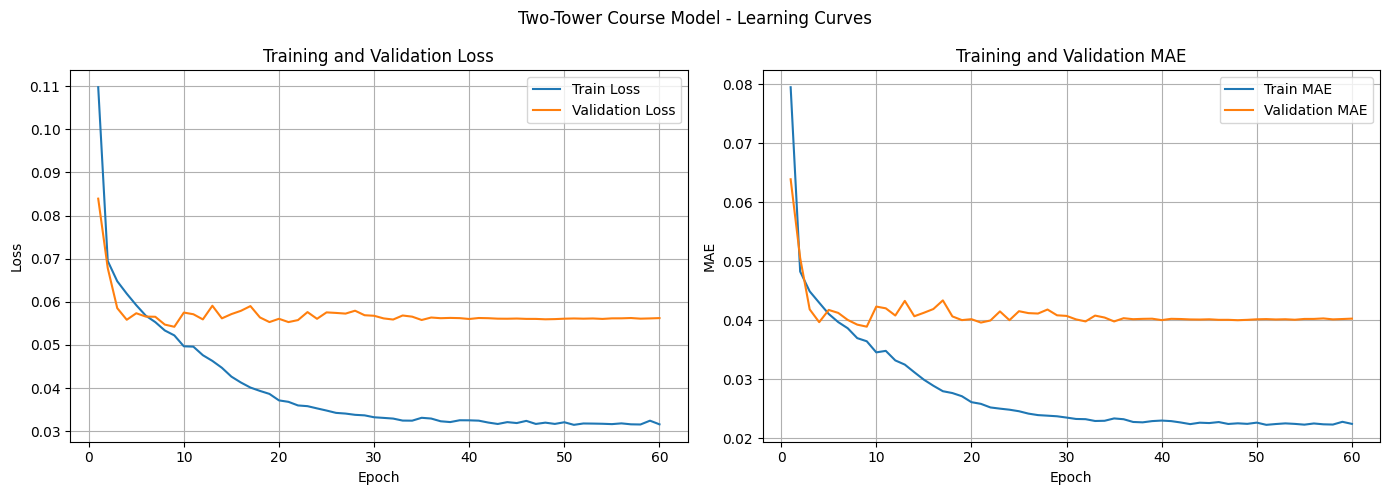

Fig 1: Learning curves (loss & MAE).


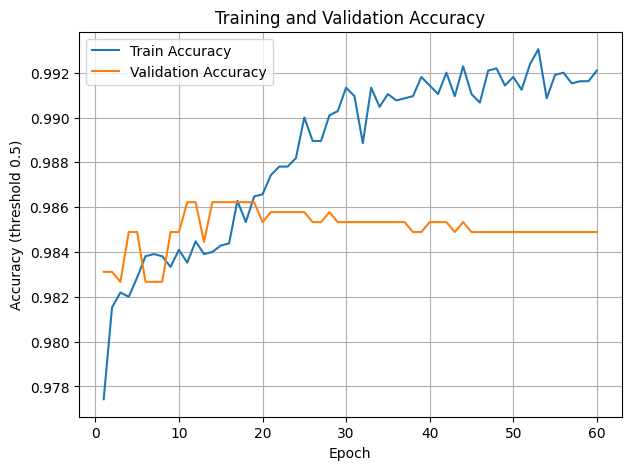

Fig 2: Accuracy curves.


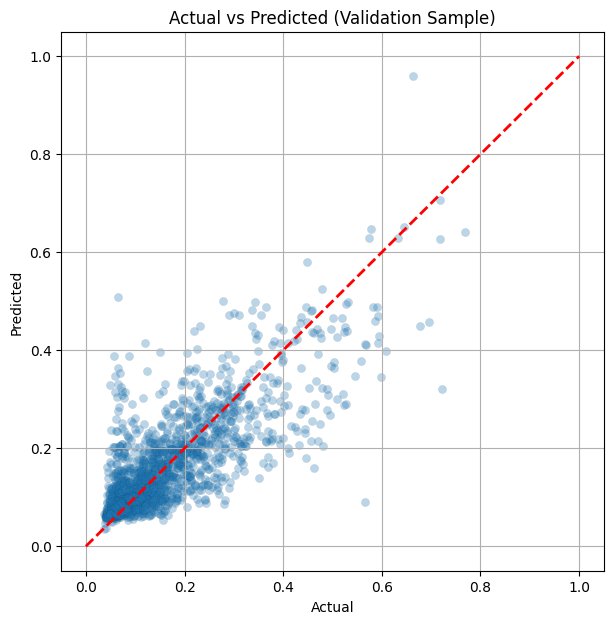

Fig 3: Scatter of actual vs predicted.


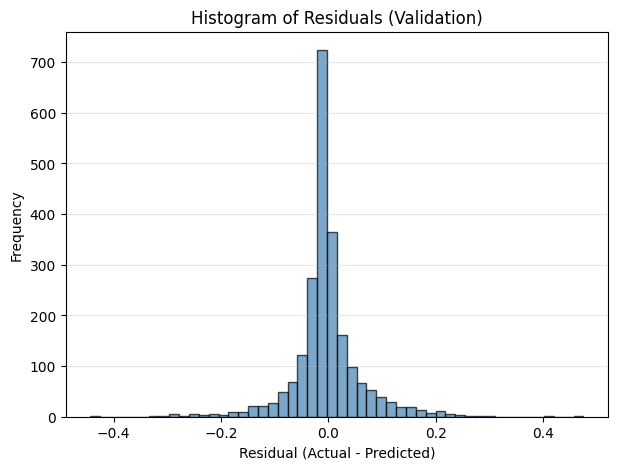

Fig 4: Residual distribution.


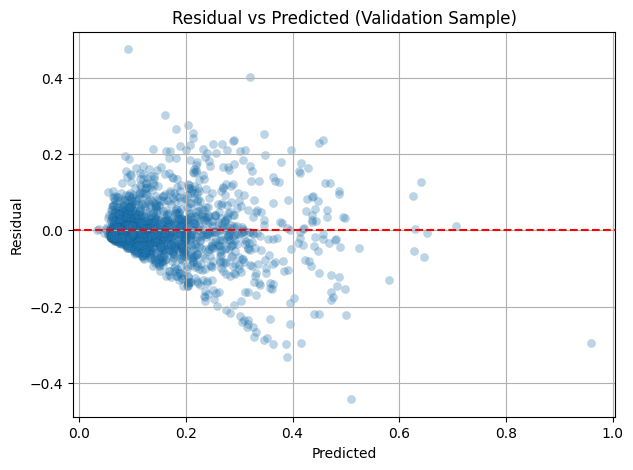

Fig 5: Residual vs predicted.


In [14]:

# ---------- Training Visualizations ----------

epochs_range = range(1, len(history4['loss'])+1)

# 1. Loss and MAE curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, history4['loss'], label='Train Loss')
ax1.plot(epochs_range, history4['val_loss'], label='Validation Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history4['mae'], label='Train MAE')
ax2.plot(epochs_range, history4['val_mae'], label='Validation MAE')
ax2.set_title('Training and Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True)
plt.suptitle('Two-Tower Course Model - Learning Curves')
plt.tight_layout()
plt.show()
print("Fig 1: Learning curves (loss & MAE).")

# 2. Accuracy curves
plt.figure(figsize=(7,5))
plt.plot(epochs_range, history4['acc'], label='Train Accuracy')
plt.plot(epochs_range, history4['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (threshold 0.5)')
plt.legend()
plt.grid(True)
plt.show()
print("Fig 2: Accuracy curves.")

# 3. Scatter plot actual vs predicted (validation)
val_preds = model4.predict(val_ds4, verbose=0)
y_val_flat = val_targets.flatten()
preds_flat = val_preds.flatten()
indices = np.random.choice(len(y_val_flat), size=min(5000, len(y_val_flat)), replace=False)
plt.figure(figsize=(7,7))
plt.scatter(y_val_flat[indices], preds_flat[indices], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.plot([0,1], [0,1], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted (Validation Sample)')
plt.grid(True)
plt.show()
print("Fig 3: Scatter of actual vs predicted.")

# 4. Histogram of residuals
residuals = y_val_flat - preds_flat
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Residuals (Validation)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 4: Residual distribution.")

# 5. Residual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(preds_flat[indices], residuals[indices], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual vs Predicted (Validation Sample)')
plt.grid(True)
plt.show()
print("Fig 5: Residual vs predicted.")

Test MAE: 0.0385, Test MSE: 0.0042, Test Accuracy (threshold 0.5): 0.9836


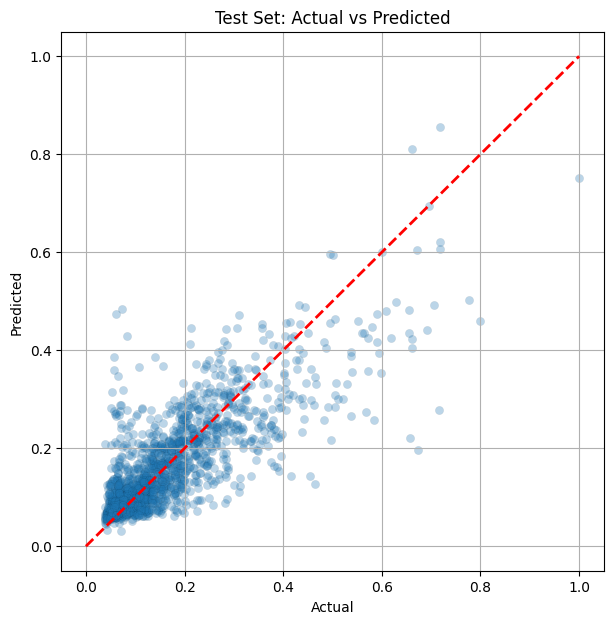

Fig 1: Scatter of actual vs predicted. Points close to diagonal indicate good predictions.


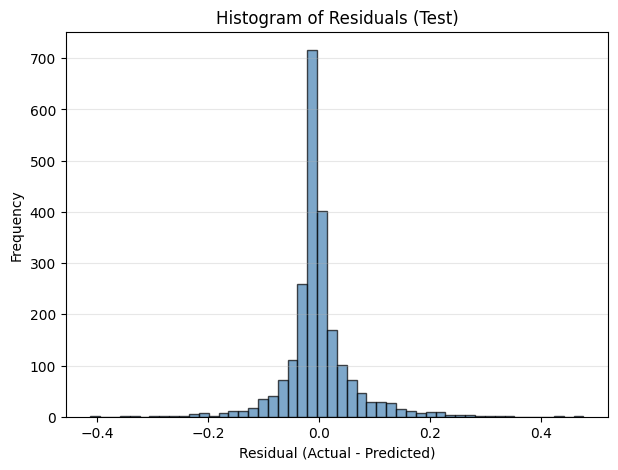

Fig 2: Residual distribution centered near zero shows unbiased predictions.


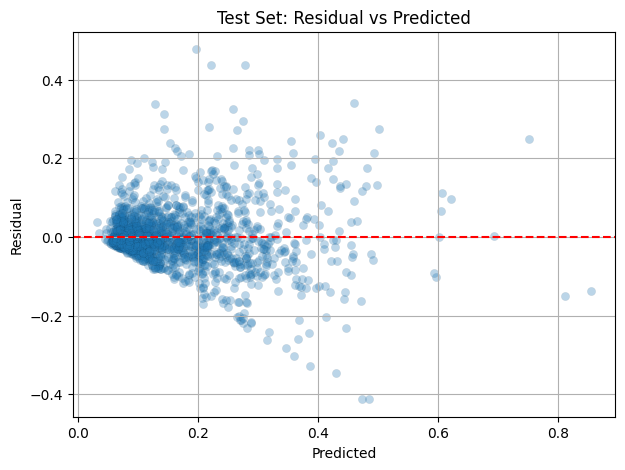

Fig 3: Residual vs predicted reveals heteroscedasticity if funnel shape appears.


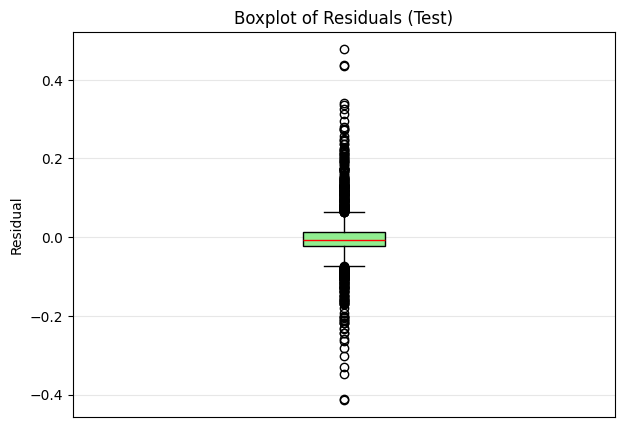

Fig 4: Boxplot shows the spread and symmetry of residuals.


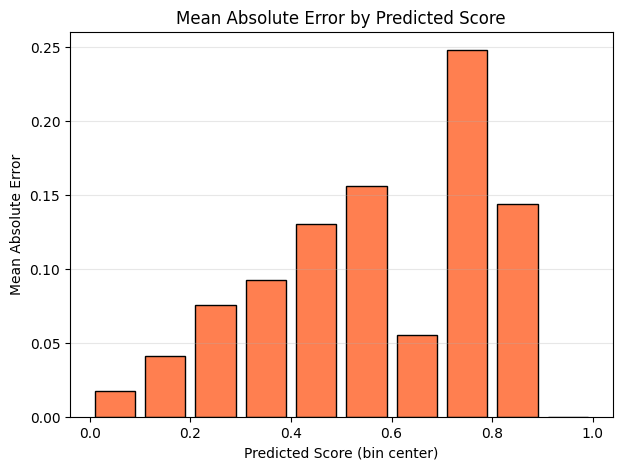

Fig 5: Error distribution across predicted scores. Higher error at extreme bins may indicate poor calibration.


In [15]:
# Two-Tower Course Model Testing: load best model, evaluate on test set, compute metrics, and plot 5 diagnostic visualizations.

import matplotlib.pyplot as plt
import numpy as np

# Load best saved model
best_model4 = tf.saved_model.load("/kaggle/working/models/two_tower_course_model_savedmodel")
infer_best4 = best_model4.signatures['serving_default']

# Prepare test data
test_demand = demand_vectors[test_idx_d]
test_course = course_vectors_selected[test_idx_d]   # (N_test, N_SKILLS_CR)
test_targets = targets[test_idx_d].reshape(-1, 1)

# Predict function (batch to avoid OOM, float16 conversion needed)
def predict_course_score(model, demand_batch, course_batch, batch_size=256):
    preds = []
    for i in range(0, len(demand_batch), batch_size):
        d = tf.constant(demand_batch[i:i+batch_size], dtype=tf.float16)
        c = tf.constant(course_batch[i:i+batch_size], dtype=tf.float16)
        out = model(args_0=d, args_0_1=c)   # adjust key names if needed
        preds.append(out['output_0'].numpy())
    return np.concatenate(preds, axis=0)

test_preds = predict_course_score(infer_best4, test_demand, test_course)

# Flatten
y_test_flat = test_targets.flatten()
preds_flat = test_preds.flatten()

# Metrics
mae_test = np.mean(np.abs(y_test_flat - preds_flat))
mse_test = np.mean((y_test_flat - preds_flat)**2)
acc_test = np.mean((y_test_flat > 0.5) == (preds_flat > 0.5))
print(f"Test MAE: {mae_test:.4f}, Test MSE: {mse_test:.4f}, Test Accuracy (threshold 0.5): {acc_test:.4f}")

# 1. Scatter Actual vs Predicted
sample_idx = np.random.choice(len(y_test_flat), size=min(5000, len(y_test_flat)), replace=False)
plt.figure(figsize=(7,7))
plt.scatter(y_test_flat[sample_idx], preds_flat[sample_idx], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.plot([0,1], [0,1], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Test Set: Actual vs Predicted')
plt.grid(True)
plt.show()
print("Fig 1: Scatter of actual vs predicted. Points close to diagonal indicate good predictions.")

# 2. Histogram of Residuals
residuals = y_test_flat - preds_flat
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Histogram of Residuals (Test)')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 2: Residual distribution centered near zero shows unbiased predictions.")

# 3. Residual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(preds_flat[sample_idx], residuals[sample_idx], alpha=0.3, edgecolor='k', linewidth=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Test Set: Residual vs Predicted')
plt.grid(True)
plt.show()
print("Fig 3: Residual vs predicted reveals heteroscedasticity if funnel shape appears.")

# 4. Boxplot of Residuals
plt.figure(figsize=(7,5))
plt.boxplot(residuals, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='black'),
            medianprops=dict(color='red'))
plt.title('Boxplot of Residuals (Test)')
plt.ylabel('Residual')
plt.xticks([])
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 4: Boxplot shows the spread and symmetry of residuals.")

# 5. Average error by predicted score bins
bins = np.linspace(0, 1, 11)  # 10 bins
bin_indices = np.digitize(preds_flat, bins)
bin_me = [np.mean(np.abs(residuals[bin_indices == i])) if np.sum(bin_indices == i) > 0 else 0 for i in range(1, len(bins))]
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(7,5))
plt.bar(bin_centers, bin_me, width=0.08, edgecolor='black', color='coral')
plt.xlabel('Predicted Score (bin center)')
plt.ylabel('Mean Absolute Error')
plt.title('Mean Absolute Error by Predicted Score')
plt.grid(axis='y', alpha=0.3)
plt.show()
print("Fig 5: Error distribution across predicted scores. Higher error at extreme bins may indicate poor calibration.")

# 6. Zip Model and Inference Test

In [16]:
zip_model_path = "/kaggle/working/saved_models.zip"
with zipfile.ZipFile(zip_model_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk("/kaggle/working/models"):
        for file in files:
            full = os.path.join(root, file)
            arcname = os.path.relpath(full, "/kaggle/working/models")
            zf.write(full, arcname)
print(f" Models zipped to {zip_model_path}")

 Models zipped to /kaggle/working/saved_models.zip


In [17]:
# Inference testing for model loading, fuzzy matching, skill prioritization, and course recommendation.

import tensorflow as tf
import numpy as np
from difflib import get_close_matches

loaded3 = tf.saved_model.load("/kaggle/working/models/skill_priority_scorer_savedmodel")
infer3 = loaded3.signatures['serving_default']
print("Skill Priority Scorer Model loaded for inference.")

loaded4 = tf.saved_model.load("/kaggle/working/models/two_tower_course_model_savedmodel")
infer4 = loaded4.signatures['serving_default']
print("Two-Tower Course Model loaded for inference.")

def fuzzy_match_skill(skill, vocab_keys, threshold=0.7):
    matches = get_close_matches(skill, vocab_keys, n=1, cutoff=threshold)
    return matches[0] if matches else None

cv_skills_raw = ["python", "sql", "node", "react", "django",
                 "mongodb", "aws", "docker", "git", "restapi"]
role_input = "Backend Developer"

cv_skills = [s.lower().strip() for s in cv_skills_raw if s.strip()]
print(f" User skills (raw) : {cv_skills_raw}")
print(f" Target role      : {role_input}\n")

user_vec_li = np.zeros((1, N_SKILLS_LI), dtype=np.float32)
vocab_li_keys = list(skill_to_idx_li.keys())

for s in cv_skills:
    if s in skill_to_idx_li:
        user_vec_li[0, skill_to_idx_li[s]] = 1.0
        print(f"   '{s}' → exact match LinkedIn")
    else:
        best = fuzzy_match_skill(s, vocab_li_keys, threshold=0.7)
        if best:
            print(f"   '{s}' → fuzzy → LinkedIn '{best}'")
            user_vec_li[0, skill_to_idx_li[best]] = 1.0
        else:
            print(f"   '{s}' tidak ditemukan, diabaikan.")

recognized = int(np.sum(user_vec_li))
print(f"\n Skill dikenali: {recognized} dari {len(cv_skills_raw)}\n")

role_idx = np.array([[role_to_idx[role_input]]], dtype=np.int32)
out3 = infer3(
    user_skills=tf.constant(user_vec_li),
    role_index=tf.constant(role_idx)
)
pred_scores_li = out3['output_0'].numpy()[0]

mask = user_vec_li[0] == 0
pred_scores_masked = np.where(mask, pred_scores_li, -1.0)
top_indices = np.argsort(pred_scores_masked)[::-1][:15]

top_skills = []
for idx in top_indices:
    if pred_scores_masked[idx] <= 0:
        continue
    skill_li = idx_to_skill_li[str(idx)]
    score_li = float(pred_scores_masked[idx])
    
    mapped_cr = []
    if skill_li in skill_to_idx_cr:
        mapped_cr.append(skill_li)
    else:
        best_cr = fuzzy_match_skill(skill_li, list(skill_to_idx_cr.keys()), threshold=0.7)
        if best_cr:
            mapped_cr.append(best_cr)
    
    if skill_li in linkedin_to_coursera:
        for cr in linkedin_to_coursera[skill_li]:
            if cr not in mapped_cr:
                mapped_cr.append(cr)
    
    top_skills.append({
        "skill_linkedin": skill_li,
        "priority_score": score_li,
        "mapped_to_coursera": mapped_cr
    })

print(" Top-15 Priority Skills (dengan mapping ke Coursera):")
for i, item in enumerate(top_skills, 1):
    li = item['skill_linkedin']
    cr = item['mapped_to_coursera']
    print(f"  {i:2d}. LinkedIn: {li:<25s} → Coursera: {cr}  (score: {item['priority_score']:.4f})")

demand_vec_li = np.zeros(N_SKILLS_LI, dtype=np.float32)
for item in top_skills:
    li = item['skill_linkedin']
    if li in skill_to_idx_li:
        demand_vec_li[skill_to_idx_li[li]] = 1.0

demand_vec_cr = np.zeros(N_SKILLS_CR, dtype=np.float32)
for item in top_skills:
    for cr in item['mapped_to_coursera']:
        if cr in skill_to_idx_cr:
            demand_vec_cr[skill_to_idx_cr[cr]] = 1.0

demand_batch = np.tile(demand_vec_li.reshape(1, -1), (num_courses, 1)).astype(np.float32)
course_batch = course_vectors_all.astype(np.float32)

demand_batch_f16 = tf.cast(tf.constant(demand_batch), tf.float16)
course_batch_f16 = tf.cast(tf.constant(course_batch), tf.float16)

kwargs4 = {
    'args_0': demand_batch_f16,
    'args_0_1': course_batch_f16
}
out4 = infer4(**kwargs4)
match_scores = list(out4.values())[0].numpy().flatten()

top_course_idx = np.argsort(match_scores)[::-1][:20]

print("\n Top-20 Recommended Courses:")
for i, cid in enumerate(top_course_idx, 1):
    score = match_scores[cid]
    row = df_coursera.iloc[cid]
    name = row['Name']
    url = row['Url']
    job_category = row.get('Job category', '')
    difficulty = row.get('Difficulty', '')
    duration = row.get('Duration', '')
    
    all_skills = [idx_to_skill_cr[str(k)] for k in range(N_SKILLS_CR)
                  if course_vectors_all[cid][k] > 0]
    covered = [idx_to_skill_cr[str(k)] for k in range(N_SKILLS_CR)
               if course_vectors_all[cid][k] > 0 and demand_vec_cr[k] > 0]

    print(f"  {i:2d}. {name:<60s} score: {score:.4f}")
    print(f"       {url}")
    print(f"       Job Category : {job_category}")
    print(f"       Difficulty   : {difficulty}")
    print(f"       Duration     : {duration}")
    print(f"       All Skills   : {all_skills}")
    print(f"       Covered      : {covered}\n")

Skill Priority Scorer Model loaded for inference.
Two-Tower Course Model loaded for inference.
 User skills (raw) : ['python', 'sql', 'node', 'react', 'django', 'mongodb', 'aws', 'docker', 'git', 'restapi']
 Target role      : Backend Developer

   'python' → exact match LinkedIn
   'sql' → fuzzy → LinkedIn 'nosql'
   'node' → fuzzy → LinkedIn 'nodejs'
   'react' → fuzzy → LinkedIn 'react.js'
   'django' → exact match LinkedIn
   'mongodb' → exact match LinkedIn
   'aws' tidak ditemukan, diabaikan.
   'docker' → exact match LinkedIn
   'git' → exact match LinkedIn
   'restapi' → fuzzy → LinkedIn 'restful api'

 Skill dikenali: 9 dari 10

 Top-15 Priority Skills (dengan mapping ke Coursera):
   1. LinkedIn: go                        → Coursera: []  (score: 0.4459)
   2. LinkedIn: kubernetes                → Coursera: ['kubernetes']  (score: 0.4345)
   3. LinkedIn: mysql                     → Coursera: ['mysql']  (score: 0.4107)
   4. LinkedIn: next.js                   → Coursera: []  (

In [ ]:
print("TensorBoard logs:")
print(f"  Skill Priority Scorer: {log_dir}")
print(f"  Two-Tower Course    : {log_dir4}")
print("Launch in notebook with: %tensorboard --logdir /kaggle/working/logs")